In [1]:
# Import required libraries
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# Check CUDA availability
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("Warning: Running on CPU. Request GPU node for faster inference.")

PyTorch Version: 2.7.1+cu118
CUDA Available: True
CUDA Device: NVIDIA H100 80GB HBM3
Number of GPUs: 8


# Cryptocurrency Sentiment Analysis - Qwen3-VL

Implementation using Qwen3-VL-8B-Instruct, a state-of-the-art multimodal vision-language model for native video understanding and visual analysis.

## Step 2: Install Required Dependencies

In [2]:
!pip install -q transformers>=4.37.0 accelerate qwen-vl-utils av pillow

import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs("./videos", exist_ok=True)
os.makedirs("./results", exist_ok=True)
os.makedirs("./temp", exist_ok=True)

print("Dependencies installed")
print("Directories created: ./videos, ./results, ./temp")

Dependencies installed
Directories created: ./videos, ./results, ./temp


## Step 3: Load Qwen3-VL-8B-Instruct Model

In [3]:
from transformers import AutoProcessor, AutoModelForVision2Seq
from qwen_vl_utils import process_vision_info
import torch

print("="*80)
print("Loading Qwen3-VL-8B-Instruct Model...")
print("="*80)

model_name = "Qwen/Qwen3-VL-8B-Instruct"

processor = AutoProcessor.from_pretrained(model_name)

model = AutoModelForVision2Seq.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("\nQwen3-VL Model loaded successfully")
print(f"Model: {model_name}")
print(f"Device: {next(model.parameters()).device}")
print(f"Dtype: {next(model.parameters()).dtype}")

Loading Qwen3-VL-8B-Instruct Model...


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/2.72G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]


Qwen3-VL Model loaded successfully
Model: Qwen/Qwen3-VL-8B-Instruct
Device: cuda:0
Dtype: torch.bfloat16


## Step 4: Qwen3-VL Video Sentiment Analyzer

In [ ]:
import re
from typing import Dict, List
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd

class Qwen3VLSentimentAnalyzer:
    """Video sentiment analyzer using Qwen3-VL-8B-Instruct"""
    
    def __init__(self, model, processor):
        self.model = model
        self.processor = processor
        
        print("="*80)
        print("Qwen3-VL Sentiment Analyzer Initialized")
        print("="*80 + "\n")
    
    def extract_video_date(self, filename: str) -> str:
        """Extract date from video filename"""
        patterns = [
            r'(\d{4}-\d{2}-\d{2})',
            r'(\d{8})',
            r'(\d{4}_\d{2}_\d{2})'
        ]
        
        for pattern in patterns:
            match = re.search(pattern, filename)
            if match:
                date_str = match.group(1).replace('_', '-')
                if len(date_str) == 8:
                    date_str = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"
                return date_str
        
        return filename
    
    def analyze_video_sentiment(self, video_path: str) -> Dict:
        """Analyze sentiment from video using Qwen3-VL with chain-of-thought reasoning"""
        prompt = """Analyze this TikTok cryptocurrency video and provide a sentiment analysis using step-by-step reasoning.

Context: This is a typical crypto TikTok video featuring a person talking directly to camera about market opinions, with accompanying charts and icons.

Step 1: Analyze the Speaker
Observe the person in the video:
- What are their facial expressions? (excited, worried, confident, fearful, neutral)
- What are their hand gestures? (pointing up=bullish, pointing down=bearish, calm=neutral)
- Does their body language convey enthusiasm or concern?
- Are they smiling or frowning?

Step 2: Analyze Visual Elements
Look at the charts and graphics displayed:
- Price charts: Are arrows or trend lines pointing up (bullish), down (bearish), or sideways (neutral)?
- Color scheme: Green dominance (bullish), red dominance (bearish), mixed colors (neutral)?
- Icons/emojis: Rockets/moons (very bullish), fire (bullish), skull/crash (bearish), question marks (uncertain)?
- Text overlays: Words like "BUY", "PUMP", "MOON" (bullish) vs "SELL", "DUMP", "CRASH" (bearish)?

Step 3: Synthesize Information
Combine speaker and visual cues:
- Do the person's emotions match the visual elements?
- Is the message consistently bullish, bearish, or mixed?
- Are there conflicting signals (e.g., worried face but green charts)?
- What is the dominant message being conveyed?

Step 4: Determine Sentiment Score
Based on all observations:
- Strong bullish signals (excited speaker + green charts + rocket icons) = score near +1.0
- Strong bearish signals (worried speaker + red charts + crash warnings) = score near -1.0
- Mixed or uncertain signals (neutral expression + sideways charts) = score near 0.0
- Confidence level: HIGH if signals are consistent, MEDIUM if somewhat mixed, LOW if very conflicting

Step 5: Final Output
Provide your analysis in this exact format:
SENTIMENT: [POSITIVE/NEGATIVE/NEUTRAL]
CONFIDENCE: [HIGH/MEDIUM/LOW]
SCORE: [number from -1.0 to +1.0]
REASONING: [brief explanation combining speaker emotion, visual elements, and overall message]
"""
        
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "video",
                        "video": str(video_path),
                        "max_pixels": 360 * 420,
                        "fps": 1.0,
                    },
                    {"type": "text", "text": prompt},
                ],
            }
        ]
        
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = self.processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )
        inputs = inputs.to(self.model.device)
        
        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False
            )
        
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        response = self.processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]
        
        result = self.parse_sentiment_response(response)
        result['raw_response'] = response
        result['method'] = 'Qwen3-VL-8B'
        
        return result
    
    def parse_sentiment_response(self, response: str) -> Dict:
        """Parse the model's sentiment response"""
        sentiment_class = 'NEUTRAL'
        confidence = 'MEDIUM'
        score = 0.0
        reasoning = response
        
        if 'SENTIMENT:' in response:
            sentiment_match = re.search(r'SENTIMENT:\s*(\w+)', response, re.IGNORECASE)
            if sentiment_match:
                sentiment_class = sentiment_match.group(1).upper()
        
        if 'CONFIDENCE:' in response:
            confidence_match = re.search(r'CONFIDENCE:\s*(\w+)', response, re.IGNORECASE)
            if confidence_match:
                confidence = confidence_match.group(1).upper()
        
        if 'SCORE:' in response:
            score_match = re.search(r'SCORE:\s*([+-]?\d+\.?\d*)', response, re.IGNORECASE)
            if score_match:
                try:
                    score = float(score_match.group(1))
                    score = max(-1.0, min(1.0, score))
                except:
                    pass
        
        if 'REASONING:' in response:
            reasoning_match = re.search(r'REASONING:\s*(.+)', response, re.IGNORECASE | re.DOTALL)
            if reasoning_match:
                reasoning = reasoning_match.group(1).strip()
        
        return {
            'sentiment_class': sentiment_class,
            'confidence': confidence,
            'sentiment_score': score,
            'reasoning': reasoning
        }
    
    def analyze_video(self, video_path: str) -> Dict:
        """Analyze a single video file"""
        print(f"\nProcessing: {Path(video_path).name}")
        
        result = {
            'date': self.extract_video_date(Path(video_path).name),
            'video_path': str(video_path),
        }
        
        try:
            print(f"  Analyzing with Qwen3-VL...")
            sentiment_result = self.analyze_video_sentiment(video_path)
            result.update(sentiment_result)
            print(f"  Sentiment: {result['sentiment_class']} (score: {result['sentiment_score']:.3f})")
        except Exception as e:
            print(f"  Error analyzing video: {e}")
            result.update({
                'sentiment_score': 0.0,
                'sentiment_class': 'NEUTRAL',
                'confidence': 'LOW',
                'reasoning': f'Error: {str(e)}',
                'method': 'Error'
            })
        
        result['timestamp'] = datetime.now().isoformat()
        return result
    
    def batch_analyze_videos(self, video_dir: str, output_csv: str = './results/sentiment_analysis_qwen.csv',
                            consolidate_by_date: bool = True):
        """Analyze all videos in a directory"""
        video_dir = Path(video_dir)
        video_extensions = ['*.mp4', '*.avi', '*.mov', '*.mkv', '*.webm']
        
        video_files = []
        for ext in video_extensions:
            video_files.extend(list(video_dir.glob(ext)))
        
        video_files = sorted(video_files)
        
        print("\n" + "="*80)
        print(f"QWEN3-VL VIDEO SENTIMENT ANALYSIS")
        print(f"Found {len(video_files)} videos to process")
        if consolidate_by_date:
            print(f"Mode: CONSOLIDATING videos by date")
        print("="*80)
        
        if len(video_files) == 0:
            print(f"No videos found in {video_dir}")
            return pd.DataFrame()
        
        if consolidate_by_date:
            videos_by_date = {}
            for video_path in video_files:
                date = self.extract_video_date(video_path.name)
                if date not in videos_by_date:
                    videos_by_date[date] = []
                videos_by_date[date].append(video_path)
            
            print(f"\nFound {len(videos_by_date)} unique dates with videos")
            
            results = []
            date_count = 0
            for date, date_videos in sorted(videos_by_date.items()):
                date_count += 1
                print(f"\n[{date_count}/{len(videos_by_date)}] Processing date: {date} ({len(date_videos)} videos)")
                print("-" * 80)
                
                all_scores = []
                video_paths = []
                
                for video_path in date_videos:
                    video_result = self.analyze_video(str(video_path))
                    all_scores.append(video_result.get('sentiment_score', 0.0))
                    video_paths.append(str(video_path))
                
                if len(all_scores) > 0:
                    avg_score = np.mean(all_scores)
                    
                    if avg_score > 0.2:
                        classification = 'POSITIVE'
                        confidence = 'HIGH' if avg_score > 0.4 else 'MEDIUM'
                    elif avg_score < -0.2:
                        classification = 'NEGATIVE'
                        confidence = 'HIGH' if avg_score < -0.4 else 'MEDIUM'
                    else:
                        classification = 'NEUTRAL'
                        confidence = 'MEDIUM'
                    
                    result = {
                        'date': date,
                        'num_videos': len(date_videos),
                        'video_paths': '; '.join([Path(p).name for p in video_paths]),
                        'sentiment_score': float(avg_score),
                        'sentiment_class': classification,
                        'confidence': confidence,
                        'method': f"Qwen3-VL - averaged {len(date_videos)} videos",
                        'timestamp': datetime.now().isoformat()
                    }
                else:
                    result = {
                        'date': date,
                        'num_videos': len(date_videos),
                        'video_paths': '; '.join([Path(p).name for p in video_paths]),
                        'sentiment_score': 0.0,
                        'sentiment_class': 'NEUTRAL',
                        'confidence': 'LOW',
                        'method': 'Fallback',
                        'timestamp': datetime.now().isoformat()
                    }
                
                results.append(result)
                print(f"Consolidated sentiment: {result['sentiment_class']} (score: {result['sentiment_score']:.3f})")
        
        else:
            results = []
            for i, video_path in enumerate(video_files, 1):
                print(f"\n[{i}/{len(video_files)}]")
                result = self.analyze_video(str(video_path))
                results.append(result)
        
        df = pd.DataFrame(results)
        
        os.makedirs(os.path.dirname(output_csv), exist_ok=True)
        df.to_csv(output_csv, index=False)
        
        print("\n" + "="*80)
        print(f"ANALYSIS COMPLETE")
        if consolidate_by_date:
            print(f"  Total unique dates processed: {len(df)}")
            print(f"  Total videos analyzed: {len(video_files)}")
            if len(df) > 0:
                print(f"  Average videos per date: {len(video_files)/len(df):.1f}")
        else:
            print(f"  Total videos processed: {len(video_files)}")
        print(f"  Results saved to: {output_csv}")
        if len(df) > 0:
            print(f"  Average sentiment score: {df['sentiment_score'].mean():.3f}")
            print(f"  Sentiment distribution:")
            print(df['sentiment_class'].value_counts().to_string())
        print("="*80 + "\n")
        
        return df

print("Qwen3VLSentimentAnalyzer class defined")

Qwen3VLSentimentAnalyzer class defined


## Step 5: Run Sentiment Analysis

In [5]:
VIDEO_DIR = "./videos"
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*80)
print("QWEN3-VL SENTIMENT ANALYSIS PIPELINE")
print("="*80)

analyzer = Qwen3VLSentimentAnalyzer(model=model, processor=processor)

results_df = analyzer.batch_analyze_videos(
    video_dir=VIDEO_DIR,
    output_csv=f"{OUTPUT_DIR}/sentiment_analysis_qwen.csv",
    consolidate_by_date=True
)

if len(results_df) > 0:
    print("\n" + "="*80)
    print("SAMPLE RESULTS")
    print("="*80)
    if 'num_videos' in results_df.columns:
        print(results_df[['date', 'num_videos', 'sentiment_score', 'sentiment_class', 'confidence']].head(10))
    else:
        print(results_df[['date', 'sentiment_score', 'sentiment_class', 'confidence']].head(10))
    
    print(f"\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    print(results_df['sentiment_score'].describe())
    print(f"\nSentiment Class Distribution:")
    print(results_df['sentiment_class'].value_counts())
else:
    print("\nWarning: No video files found in", VIDEO_DIR)

QWEN3-VL SENTIMENT ANALYSIS PIPELINE
Qwen3-VL Sentiment Analyzer Initialized


QWEN3-VL VIDEO SENTIMENT ANALYSIS
Found 39 videos to process
Mode: CONSOLIDATING videos by date

Found 17 unique dates with videos

[1/17] Processing date: 2025-01-31 (2 videos)
--------------------------------------------------------------------------------

Processing: 2025_01_31.mp4
  Analyzing with Qwen3-VL...


qwen-vl-utils using decord to read video.
Asked to sample `fps` frames per second but no video metadata was provided which is required when sampling with `fps`. Defaulting to `fps=24`. Please provide `video_metadata` for more accurate results.
Asked to sample `fps` frames per second but no video metadata was provided which is required when sampling with `fps`. Defaulting to `fps=24`. Please provide `video_metadata` for more accurate results.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sentiment: NEGATIVE (score: -0.900)

Processing: 2025_01_31_1.mp4
  Analyzing with Qwen3-VL...
  Sentiment: POSITIVE (score: 0.900)
Consolidated sentiment: NEUTRAL (score: 0.000)

[2/17] Processing date: 2025-02-04 (2 videos)
--------------------------------------------------------------------------------

Processing: 2025_02_04.mp4
  Analyzing with Qwen3-VL...
  Sentiment: POSITIVE (score: 0.900)
Consolidated sentiment: NEUTRAL (score: 0.000)

[2/17] Processing date: 2025-02-04 (2 videos)
--------------------------------------------------------------------------------

Processing: 2025_02_04.mp4
  Analyzing with Qwen3-VL...
  Sentiment: NEUTRAL (score: 0.000)

Processing: 2025_02_04_1.mp4
  Analyzing with Qwen3-VL...
  Sentiment: NEUTRAL (score: 0.000)

Processing: 2025_02_04_1.mp4
  Analyzing with Qwen3-VL...
  Sentiment: POSITIVE (score: 0.900)
Consolidated sentiment: POSITIVE (score: 0.450)

[3/17] Processing date: 2025-02-06 (6 videos)
-------------------------------------------

## Step 6: Visualization - Sentiment vs. Price

yfinance available
CREATING SENTIMENT VS PRICE VISUALIZATION

Fetching Dogecoin price data from 2025-01-30 to 2025-03-01...
Fetched 30 days of price data
Fetched 30 days of price data
Plot saved to: ./results/sentiment_vs_price_qwen.png
Plot saved to: ./results/sentiment_vs_price_qwen.png


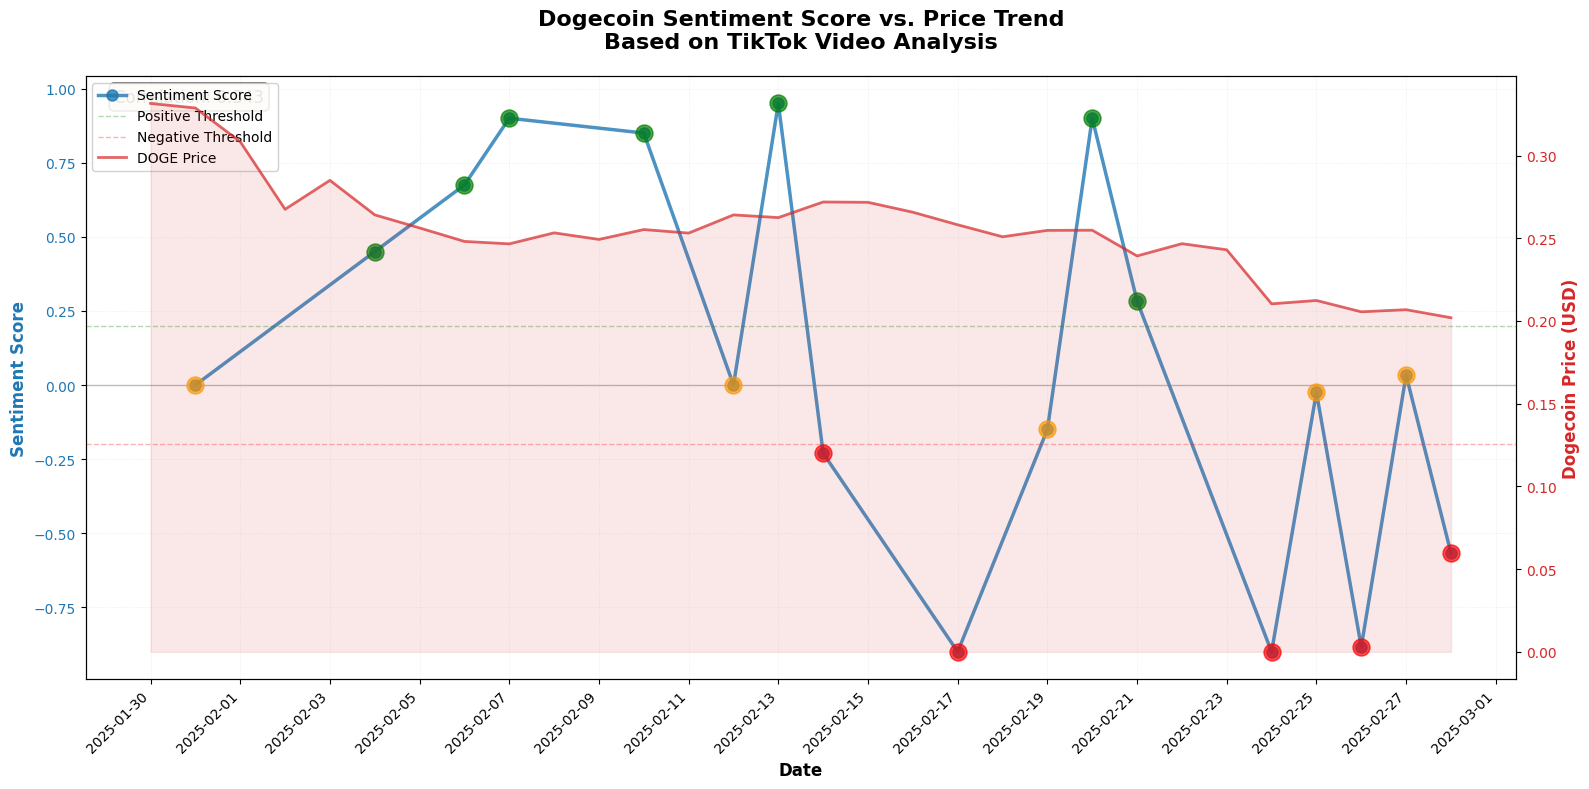


SENTIMENT VS PRICE SUMMARY

Sentiment Statistics:
  Mean sentiment: 0.082
  Std deviation:  0.646
  Min sentiment:  -0.900 on 2025-02-17
  Max sentiment:  0.950 on 2025-02-13

Price Statistics:
  Mean price:     $0.2556
  Std deviation:  $0.0311
  Min price:      $0.2020
  Max price:      $0.3315
  Price change:   -39.08%

Correlation Analysis:
  Pearson correlation: 0.343
  Weak correlation


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd

try:
    import yfinance as yf
    print("yfinance available")
except ImportError:
    print("Installing yfinance...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'yfinance', '-q'])
    import yfinance as yf
    print("yfinance installed")

def plot_sentiment_vs_price(sentiment_csv: str = './results/sentiment_analysis_qwen.csv'):
    """Create a dual-axis plot showing sentiment scores and cryptocurrency price"""
    sentiment_df = pd.read_csv(sentiment_csv)
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
    sentiment_df = sentiment_df.sort_values('date')
    
    start_date = sentiment_df['date'].min() - timedelta(days=1)
    end_date = sentiment_df['date'].max() + timedelta(days=1)
    
    print(f"Fetching Dogecoin price data from {start_date.date()} to {end_date.date()}...")
    
    try:
        doge = yf.Ticker("DOGE-USD")
        price_df = doge.history(start=start_date, end=end_date)
        
        if len(price_df) == 0:
            print("Warning: No price data returned. Using mock data.")
            dates = pd.date_range(start=start_date, end=end_date, freq='D')
            price_df = pd.DataFrame({
                'Close': [0.15 + i*0.001 for i in range(len(dates))]
            }, index=dates)
        else:
            print(f"Fetched {len(price_df)} days of price data")
        
        price_df.index = pd.to_datetime(price_df.index)
        
    except Exception as e:
        print(f"Error fetching price data: {e}")
        dates = pd.date_range(start=start_date, end=end_date, freq='D')
        price_df = pd.DataFrame({
            'Close': [0.15 + i*0.001 for i in range(len(dates))]
        }, index=dates)
    
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    color1 = 'tab:blue'
    ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Sentiment Score', color=color1, fontsize=12, fontweight='bold')
    
    line1 = ax1.plot(sentiment_df['date'], sentiment_df['sentiment_score'], 
                     color=color1, linewidth=2.5, marker='o', markersize=8, 
                     label='Sentiment Score', alpha=0.8)
    
    ax1.axhline(y=0.2, color='green', linestyle='--', alpha=0.3, linewidth=1, label='Positive Threshold')
    ax1.axhline(y=-0.2, color='red', linestyle='--', alpha=0.3, linewidth=1, label='Negative Threshold')
    ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.5, linewidth=1)
    
    for idx, row in sentiment_df.iterrows():
        if row['sentiment_score'] > 0.2:
            ax1.scatter(row['date'], row['sentiment_score'], color='green', s=150, zorder=5, alpha=0.7)
        elif row['sentiment_score'] < -0.2:
            ax1.scatter(row['date'], row['sentiment_score'], color='red', s=150, zorder=5, alpha=0.7)
        else:
            ax1.scatter(row['date'], row['sentiment_score'], color='orange', s=150, zorder=5, alpha=0.7)
    
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('Dogecoin Price (USD)', color=color2, fontsize=12, fontweight='bold')
    
    line2 = ax2.plot(price_df.index, price_df['Close'], 
                     color=color2, linewidth=2, label='DOGE Price', alpha=0.7)
    ax2.fill_between(price_df.index, price_df['Close'], alpha=0.1, color=color2)
    
    ax2.tick_params(axis='y', labelcolor=color2)
    
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.title('Dogecoin Sentiment Score vs. Price Trend\nBased on TikTok Video Analysis', 
              fontsize=16, fontweight='bold', pad=20)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10, framealpha=0.9)
    
    price_df.index = price_df.index.tz_localize(None)
    
    merged_df = sentiment_df.set_index('date')[['sentiment_score']].join(
        price_df[['Close']].rename(columns={'Close': 'price'}), 
        how='inner'
    )
    
    if len(merged_df) > 1:
        correlation = merged_df['sentiment_score'].corr(merged_df['price'])
        textstr = f'Correlation: {correlation:.3f}'
        ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    output_path = './results/sentiment_vs_price_qwen.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {output_path}")
    
    plt.show()
    
    print("\n" + "="*80)
    print("SENTIMENT VS PRICE SUMMARY")
    print("="*80)
    print(f"\nSentiment Statistics:")
    print(f"  Mean sentiment: {sentiment_df['sentiment_score'].mean():.3f}")
    print(f"  Std deviation:  {sentiment_df['sentiment_score'].std():.3f}")
    print(f"  Min sentiment:  {sentiment_df['sentiment_score'].min():.3f} on {sentiment_df.loc[sentiment_df['sentiment_score'].idxmin(), 'date'].date()}")
    print(f"  Max sentiment:  {sentiment_df['sentiment_score'].max():.3f} on {sentiment_df.loc[sentiment_df['sentiment_score'].idxmax(), 'date'].date()}")
    
    print(f"\nPrice Statistics:")
    if len(price_df) > 0:
        print(f"  Mean price:     ${price_df['Close'].mean():.4f}")
        print(f"  Std deviation:  ${price_df['Close'].std():.4f}")
        print(f"  Min price:      ${price_df['Close'].min():.4f}")
        print(f"  Max price:      ${price_df['Close'].max():.4f}")
        print(f"  Price change:   {((price_df['Close'].iloc[-1] - price_df['Close'].iloc[0]) / price_df['Close'].iloc[0] * 100):.2f}%")
    
    if len(merged_df) > 1:
        print(f"\nCorrelation Analysis:")
        print(f"  Pearson correlation: {correlation:.3f}")
        if abs(correlation) > 0.7:
            print(f"  Strong {'positive' if correlation > 0 else 'negative'} correlation")
        elif abs(correlation) > 0.4:
            print(f"  Moderate {'positive' if correlation > 0 else 'negative'} correlation")
        else:
            print(f"  Weak correlation")
    
    print("="*80)
    
    return sentiment_df, price_df

print("="*80)
print("CREATING SENTIMENT VS PRICE VISUALIZATION")
print("="*80 + "\n")

sentiment_data, price_data = plot_sentiment_vs_price('./results/sentiment_analysis_qwen.csv')

## Step 7: Volatility Analysis

CREATING VOLATILITY ANALYSIS



Fetching Dogecoin price data from 2025-01-30 to 2025-03-01...
Fetched 30 days of price data
Calculated volatility metrics
Plot saved to: ./results/sentiment_vs_volatility_qwen.png
Plot saved to: ./results/sentiment_vs_volatility_qwen.png


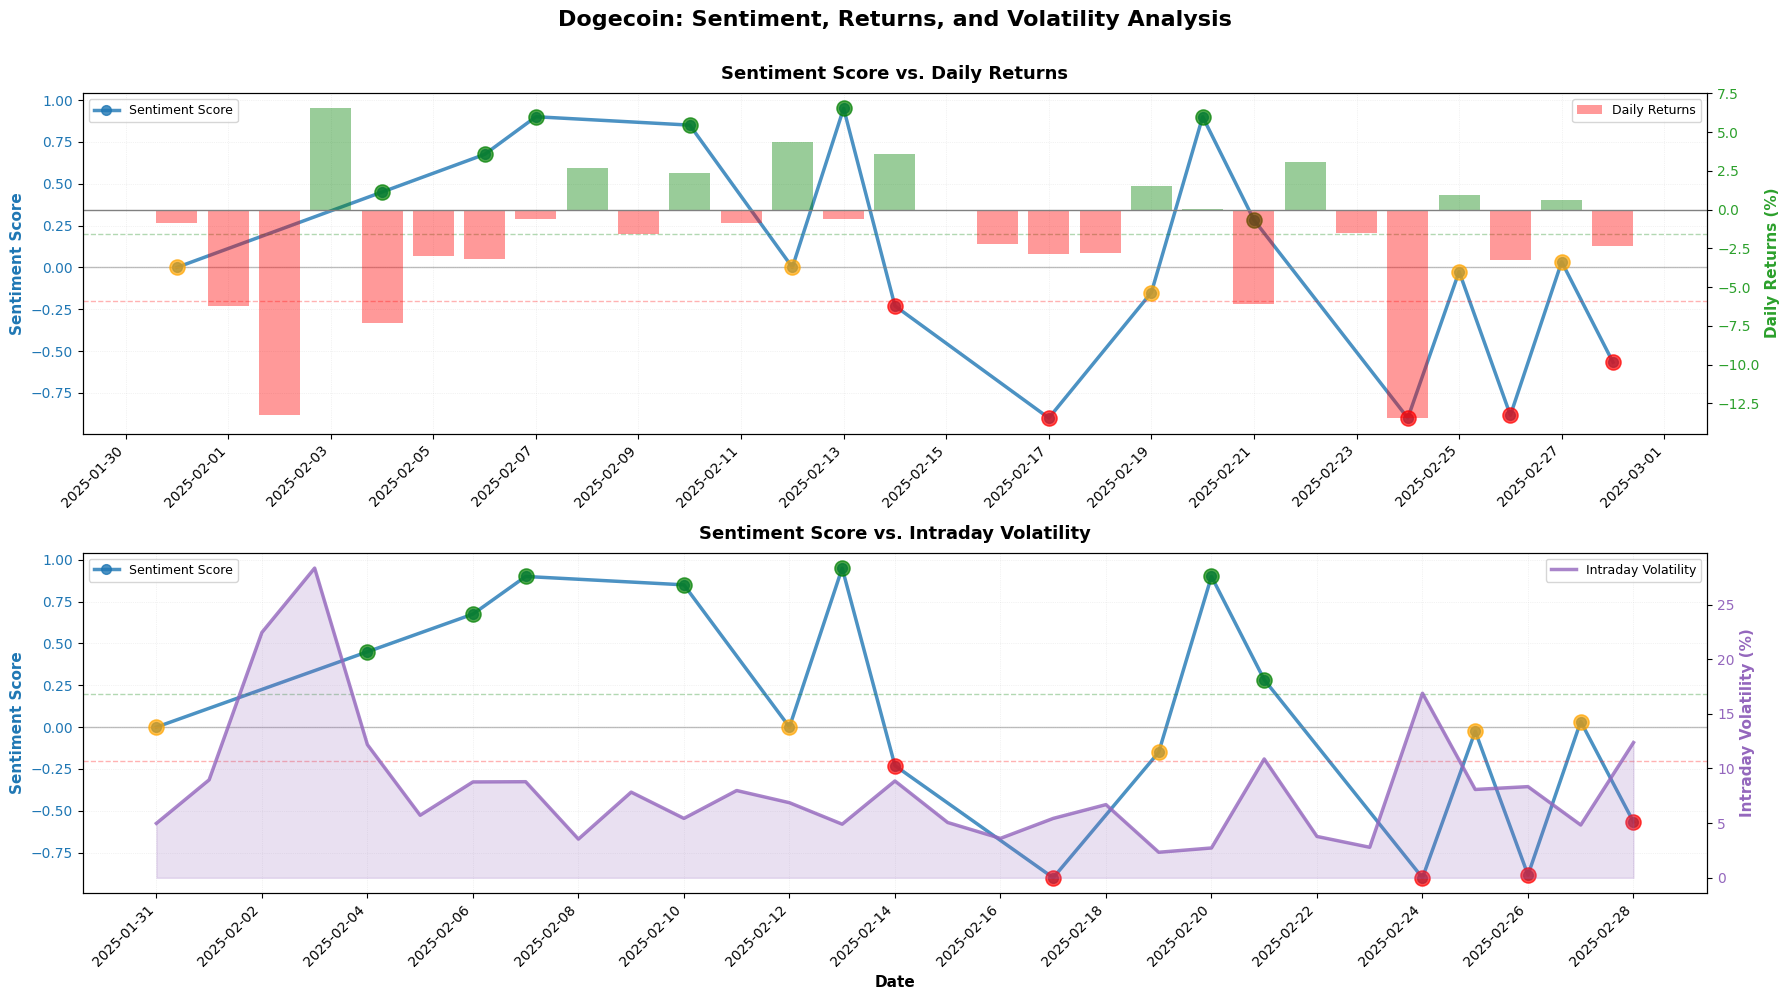


SENTIMENT VS RETURNS AND VOLATILITY ANALYSIS

Sentiment Statistics:
  Mean sentiment:      0.082
  Std deviation:       0.646
  Min sentiment:       -0.900
  Max sentiment:       0.950

Price & Returns:
  Mean price:          $0.2530
  Total return:        -38.56%
  Mean daily return:   -1.590%
  Std deviation:       4.534%

Volatility:
  Mean intraday vol:   8.253%
  Annualized vol:      157.68%

Correlation Analysis:
  Sentiment vs Returns:     +0.305
  Sentiment vs Volatility:  -0.348
  Sentiment vs Next-day Returns: -0.019
  Sentiment vs Next-day Vol:     +0.349

Data saved to: ./results/sentiment_volatility_analysis_qwen.csv


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

def plot_sentiment_vs_volatility(sentiment_csv: str = './results/sentiment_analysis_qwen.csv'):
    """Create plots showing sentiment scores vs returns and volatility"""
    sentiment_df = pd.read_csv(sentiment_csv)
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
    sentiment_df = sentiment_df.sort_values('date')
    
    start_date = sentiment_df['date'].min() - timedelta(days=1)
    end_date = sentiment_df['date'].max() + timedelta(days=1)
    
    print(f"Fetching Dogecoin price data from {start_date.date()} to {end_date.date()}...")
    
    try:
        import yfinance as yf
        doge = yf.Ticker("DOGE-USD")
        price_df = doge.history(start=start_date, end=end_date)
        
        if len(price_df) == 0:
            print("Warning: No price data returned")
            return None, None
        
        print(f"Fetched {len(price_df)} days of price data")
        price_df.index = price_df.index.tz_localize(None)
        
    except Exception as e:
        print(f"Error fetching price data: {e}")
        return None, None
    
    price_df['returns'] = price_df['Close'].pct_change() * 100
    price_df['intraday_volatility'] = ((price_df['High'] - price_df['Low']) / price_df['Close']) * 100
    price_df['volatility'] = price_df['intraday_volatility']
    price_df['volatility_annualized'] = price_df['volatility'] * np.sqrt(365)
    
    print(f"Calculated volatility metrics")
    
    volatility_df = price_df[price_df.index >= sentiment_df['date'].min()].copy()
    
    fig = plt.figure(figsize=(18, 10))
    
    ax1 = plt.subplot(2, 1, 1)
    color1 = 'tab:blue'
    ax1.set_ylabel('Sentiment Score', color=color1, fontsize=11, fontweight='bold')
    
    ax1.plot(sentiment_df['date'], sentiment_df['sentiment_score'], 
             color=color1, linewidth=2.5, marker='o', markersize=7, 
             label='Sentiment Score', alpha=0.8)
    
    for idx, row in sentiment_df.iterrows():
        if row['sentiment_score'] > 0.2:
            ax1.scatter(row['date'], row['sentiment_score'], color='green', s=120, zorder=5, alpha=0.7)
        elif row['sentiment_score'] < -0.2:
            ax1.scatter(row['date'], row['sentiment_score'], color='red', s=120, zorder=5, alpha=0.7)
        else:
            ax1.scatter(row['date'], row['sentiment_score'], color='orange', s=120, zorder=5, alpha=0.7)
    
    ax1.axhline(y=0.2, color='green', linestyle='--', alpha=0.3, linewidth=1)
    ax1.axhline(y=-0.2, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.5, linewidth=1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    
    ax1_twin = ax1.twinx()
    color2 = 'tab:green'
    ax1_twin.set_ylabel('Daily Returns (%)', color=color2, fontsize=11, fontweight='bold')
    
    returns_colors = ['green' if r > 0 else 'red' for r in volatility_df['returns']]
    ax1_twin.bar(volatility_df.index, volatility_df['returns'], 
                 color=returns_colors, alpha=0.4, label='Daily Returns', width=0.8)
    ax1_twin.axhline(y=0, color='gray', linestyle='-', linewidth=1)
    ax1_twin.tick_params(axis='y', labelcolor=color2)
    
    ax1.set_title('Sentiment Score vs. Daily Returns', fontsize=13, fontweight='bold', pad=10)
    ax1.legend(loc='upper left', fontsize=9)
    ax1_twin.legend(loc='upper right', fontsize=9)
    
    ax2 = plt.subplot(2, 1, 2)
    color3 = 'tab:blue'
    ax2.set_ylabel('Sentiment Score', color=color3, fontsize=11, fontweight='bold')
    
    ax2.plot(sentiment_df['date'], sentiment_df['sentiment_score'], 
             color=color3, linewidth=2.5, marker='o', markersize=7, 
             label='Sentiment Score', alpha=0.8)
    
    for idx, row in sentiment_df.iterrows():
        if row['sentiment_score'] > 0.2:
            ax2.scatter(row['date'], row['sentiment_score'], color='green', s=120, zorder=5, alpha=0.7)
        elif row['sentiment_score'] < -0.2:
            ax2.scatter(row['date'], row['sentiment_score'], color='red', s=120, zorder=5, alpha=0.7)
        else:
            ax2.scatter(row['date'], row['sentiment_score'], color='orange', s=120, zorder=5, alpha=0.7)
    
    ax2.axhline(y=0.2, color='green', linestyle='--', alpha=0.3, linewidth=1)
    ax2.axhline(y=-0.2, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5, linewidth=1)
    ax2.tick_params(axis='y', labelcolor=color3)
    ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    
    ax2_twin = ax2.twinx()
    color4 = 'tab:purple'
    ax2_twin.set_ylabel('Intraday Volatility (%)', color=color4, fontsize=11, fontweight='bold')
    ax2_twin.plot(volatility_df.index, volatility_df['volatility'], 
                  color=color4, linewidth=2.5, label='Intraday Volatility', alpha=0.8)
    ax2_twin.fill_between(volatility_df.index, volatility_df['volatility'], 
                          alpha=0.2, color=color4)
    ax2_twin.tick_params(axis='y', labelcolor=color4)
    
    ax2.set_title('Sentiment Score vs. Intraday Volatility', 
                  fontsize=13, fontweight='bold', pad=10)
    ax2.legend(loc='upper left', fontsize=9)
    ax2_twin.legend(loc='upper right', fontsize=9)
    
    for ax in [ax1, ax2]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
    
    fig.suptitle('Dogecoin: Sentiment, Returns, and Volatility Analysis', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    output_path = './results/sentiment_vs_volatility_qwen.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {output_path}")
    
    plt.show()
    
    merged_df = sentiment_df.set_index('date')[['sentiment_score']].join(
        volatility_df[['Close', 'returns', 'volatility', 'volatility_annualized']], 
        how='inner'
    )
    merged_df = merged_df.rename(columns={'Close': 'price'})
    
    print("\n" + "="*80)
    print("SENTIMENT VS RETURNS AND VOLATILITY ANALYSIS")
    print("="*80)
    
    print(f"\nSentiment Statistics:")
    print(f"  Mean sentiment:      {sentiment_df['sentiment_score'].mean():.3f}")
    print(f"  Std deviation:       {sentiment_df['sentiment_score'].std():.3f}")
    print(f"  Min sentiment:       {sentiment_df['sentiment_score'].min():.3f}")
    print(f"  Max sentiment:       {sentiment_df['sentiment_score'].max():.3f}")
    
    print(f"\nPrice & Returns:")
    print(f"  Mean price:          ${volatility_df['Close'].mean():.4f}")
    print(f"  Total return:        {((volatility_df['Close'].iloc[-1] - volatility_df['Close'].iloc[0]) / volatility_df['Close'].iloc[0] * 100):.2f}%")
    
    returns_clean = volatility_df['returns'].dropna()
    if len(returns_clean) > 0:
        print(f"  Mean daily return:   {returns_clean.mean():.3f}%")
        print(f"  Std deviation:       {returns_clean.std():.3f}%")
    
    print(f"\nVolatility:")
    vol_clean = volatility_df['volatility'].dropna()
    if len(vol_clean) > 0:
        print(f"  Mean intraday vol:   {vol_clean.mean():.3f}%")
        print(f"  Annualized vol:      {volatility_df['volatility_annualized'].mean():.2f}%")
    
    if len(merged_df) > 1:
        print(f"\nCorrelation Analysis:")
        corr_returns = merged_df['sentiment_score'].corr(merged_df['returns'])
        corr_vol = merged_df['sentiment_score'].corr(merged_df['volatility'])
        
        print(f"  Sentiment vs Returns:     {corr_returns:+.3f}")
        print(f"  Sentiment vs Volatility:  {corr_vol:+.3f}")
        
        if len(merged_df) > 2:
            merged_df['next_day_returns'] = merged_df['returns'].shift(-1)
            merged_df['next_day_volatility'] = merged_df['volatility'].shift(-1)
            corr_lag_returns = merged_df['sentiment_score'].corr(merged_df['next_day_returns'])
            corr_lag_vol = merged_df['sentiment_score'].corr(merged_df['next_day_volatility'])
            print(f"  Sentiment vs Next-day Returns: {corr_lag_returns:+.3f}")
            print(f"  Sentiment vs Next-day Vol:     {corr_lag_vol:+.3f}")
    
    print("="*80)
    
    output_csv = './results/sentiment_volatility_analysis_qwen.csv'
    merged_df.to_csv(output_csv)
    print(f"\nData saved to: {output_csv}")
    
    return sentiment_df, volatility_df

print("="*80)
print("CREATING VOLATILITY ANALYSIS")
print("="*80 + "\n")

sentiment_data, volatility_data = plot_sentiment_vs_volatility(
    sentiment_csv='./results/sentiment_analysis_qwen.csv'
)

## Summary

This notebook implements cryptocurrency sentiment analysis using Qwen3-VL-8B-Instruct for native video understanding.

Key components:
- Qwen3-VL-8B-Instruct model for multimodal video analysis
- Native video processing without audio extraction
- Visual analysis of charts, text overlays, and emotional content
- Sentiment correlation with price movements and volatility

Output files:
- sentiment_analysis_qwen.csv: Sentiment scores by date
- sentiment_vs_price_qwen.png: Price correlation visualization
- sentiment_vs_volatility_qwen.png: Volatility analysis visualization
- sentiment_volatility_analysis_qwen.csv: Detailed correlation data